# RheolNet Task 1.4 — Adam → L-BFGS two-phase trainer

This notebook validates a reusable `PINNTrainer` on the proven ST40 mixed
Carreau–Yasuda PINN. It starts from the physics-only **Fourier OFF** Task 1.3
checkpoint, runs resampled Adam with cosine scheduling and gradient clipping,
then performs deterministic full-float32 L-BFGS refinement.

The Task 1.4 gate is software and reproducibility focused:

- Adam and L-BFGS both run end-to-end;
- component losses, fixed physics metrics and runtime are logged;
- loss curves are generated;
- optimizer, scheduler and adaptive-weight state are checkpointed;
- a fresh model reloads the final checkpoint with identical predictions.

No CFD solution values enter either optimizer, the fixed diagnostic, adaptive
weights or checkpoint selection. Five OpenFOAM profiles are loaded only after
the final model is frozen as a secondary regression check. Fourier remains OFF
because both controlled Task 1.3 experiments found that it worsened ST40's fixed
PDE score.


In [1]:
# GPU environment - tuned for a Kaggle NVIDIA T4 without reinstalling PyTorch.
import gc, hashlib, inspect, json, math, os, random, shutil, subprocess, sys, time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm.auto import trange

SEED = 20260916
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
ALLOW_CPU_SMOKE = os.getenv("RHEOLNET_ALLOW_CPU_SMOKE", "0") == "1"
if not torch.cuda.is_available() and not ALLOW_CPU_SMOKE:
    raise RuntimeError("CUDA unavailable. In Kaggle select Accelerator -> GPU T4, restart, then run all.")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
if device.type == "cuda":
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_CAPABILITY = torch.cuda.get_device_capability(0)
    print("GPU:", GPU_NAME, "| capability:", GPU_CAPABILITY,
          "| torch:", torch.__version__, "| CUDA:", torch.version.cuda)
    if "T4" not in GPU_NAME.upper(): print("WARNING: schedule is tuned for a T4.")
    if GPU_CAPABILITY < (7, 5): raise RuntimeError("T4-class sm_75 or newer GPU required.")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    GPU_NAME, GPU_CAPABILITY = "CPU smoke test", None
print("mixed-PINN derivative dtype:", DTYPE, "| device:", device)


GPU: Tesla T4 | capability: (7, 5) | torch: 2.10.0+cu128 | CUDA: 12.8
mixed-PINN derivative dtype: torch.float32 | device: cuda:0


In [3]:
# Reproducible repository setup. PyTorch is preinstalled on Kaggle.
REPO_DIR = Path("/kaggle/working/RheolNet")
BRANCH = "Atharva_pinn-core-baseline"
REPOSITORY_URL = "https://github.com/ath4trva/RheolNet.git"
if not REPO_DIR.exists():
    subprocess.check_call(["git", "clone", "--branch", BRANCH, "--single-branch", REPOSITORY_URL, str(REPO_DIR)])
else:
    subprocess.check_call(["git", "pull", "--ff-only", "origin", BRANCH], cwd=REPO_DIR)
if str(REPO_DIR) in sys.path: sys.path.remove(str(REPO_DIR))
sys.path.insert(0, str(REPO_DIR))
import importlib
for module_name in list(sys.modules):
    if module_name in {"geometry", "cfd", "validation", "models", "training"} or module_name.startswith(("geometry.", "cfd.", "validation.", "models.", "training.")):
        del sys.modules[module_name]
importlib.invalidate_caches()
COMMIT = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_DIR, text=True).strip()

from geometry.planar_stenosis_sampling import (
    sample_interior_points, sample_wall_points, sample_inlet_points, sample_outlet_points,
)
try:
    from cfd.planar_stenosis_cfd import load_planar_stenosis_case, validate_planar_stenosis_case
    CFD_MODULE_LAYOUT = "canonical cfd/"
except ModuleNotFoundError:
    from geometry.planar_stenosis_cfd import load_planar_stenosis_case, validate_planar_stenosis_case
    CFD_MODULE_LAYOUT = "legacy geometry/ fallback"
try:
    from validation.planar_stenosis_metrics import relative_l2_error, evaluate_planar_stenosis_field
    VALIDATION_MODULE_LAYOUT = "canonical validation/"
except ModuleNotFoundError:
    from geometry.planar_stenosis_metrics import relative_l2_error, evaluate_planar_stenosis_field
    VALIDATION_MODULE_LAYOUT = "legacy geometry/ fallback"

from models.bloodflow_pinn import BloodFlowPINN
from training.pinn_trainer import AdamPhase, LBFGSPhase, PINNTrainer
from training.checkpointing import load_torch_checkpoint

print("branch:", BRANCH); print("commit:", COMMIT)
print("CFD loader:", CFD_MODULE_LAYOUT, "| metrics:", VALIDATION_MODULE_LAYOUT)
for obj in (sample_interior_points, load_planar_stenosis_case, relative_l2_error, PINNTrainer):
    print(f"{obj.__name__:38s} {inspect.getfile(obj)}")


Updating 16757b9..50a7654
Fast-forward
 notebooks/task_1_4_adam_lbfgs_trainer_t4.ipynb |   0
 training/__init__.py                           |   5 +
 training/checkpointing.py                      |  52 +++
 training/pinn_trainer.py                       | 497 +++++++++++++++++++++++++
 training/tests/test_pinn_trainer.py            |  91 +++++
 training/trainer.py                            |   5 +
 6 files changed, 650 insertions(+)
 create mode 100644 notebooks/task_1_4_adam_lbfgs_trainer_t4.ipynb
 create mode 100644 training/checkpointing.py
 create mode 100644 training/pinn_trainer.py
 create mode 100644 training/tests/test_pinn_trainer.py
branch: Atharva_pinn-core-baseline
commit: 50a765458e4458a964ca41a62081d49a8811dbdf
CFD loader: legacy geometry/ fallback | metrics: legacy geometry/ fallback
sample_interior_points                 /kaggle/working/RheolNet/geometry/planar_stenosis_sampling.py
load_planar_stenosis_case              /kaggle/working/RheolNet/geometry/planar_stenosi

From https://github.com/ath4trva/RheolNet
 * branch            Atharva_pinn-core-baseline -> FETCH_HEAD
   16757b9..50a7654  Atharva_pinn-core-baseline -> origin/Atharva_pinn-core-baseline


In [4]:
# Flattened Kaggle dataset -> canonical RheolNet case layout.
DATASET_ROOT = Path("/kaggle/input/datasets/nightfury22344/p2d-st40-re500")
ST40_DIR = Path("/kaggle/working/P2D_ST40_Re500")
OUTPUT_DIR = Path("/kaggle/working/task_1_4_adam_lbfgs")
for sub in ("checkpoints", "figures", "metrics", "logs"):
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

required = {
    "case_metadata.json": "case_metadata.json",
    "full_field.csv": "full_field.csv",
    "mesh_independence.csv": "mesh_independence.csv",
    "blockMeshDict": "OpenFOAM_case/system/blockMeshDict",
    "U": "OpenFOAM_case/0/U",
}
missing = [name for name in required if not (DATASET_ROOT / name).is_file()]
if missing: raise FileNotFoundError(f"Missing flattened dataset files: {missing}")
for src, dst in required.items():
    target = ST40_DIR / dst; target.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(DATASET_ROOT / src, target)
profile_sources = sorted(DATASET_ROOT.glob("profile_*.csv"))
if len(profile_sources) != 5: raise RuntimeError(f"Expected five profile files, found {len(profile_sources)}")
profile_dir = ST40_DIR / "velocity_profiles"; profile_dir.mkdir(parents=True, exist_ok=True)
for path in profile_sources: shutil.copy2(path, profile_dir / path.name)
print("case:", ST40_DIR); print("outputs:", OUTPUT_DIR)


case: /kaggle/working/P2D_ST40_Re500
outputs: /kaggle/working/task_1_4_adam_lbfgs


,value
n_field_points,110400
n_unique_coordinates,110400
n_streamwise_locations,920
min_points_per_streamwise_location,120
max_points_per_streamwise_location,120
all_points_inside_geometry,True
inlet_profile_points,120


,field,minimum,maximum
0,u,-0.001362,0.599952
1,v,-0.026676,0.026676
2,p,-52.070774,80.434425
3,viscosity,0.003687,0.049159


,mesh,cells,Umax_m_s,pMin,pMax,nuMin_m2_s,nuMax_m2_s,nuAvg_m2_s,Qin_m3_s,Qout_m3_s,convergence_iteration,throat_centreline_Ux_m_s,medium_to_fine_throat_change_percent,grid_independence_result
0,coarse,6900,0.599826,-0.048957,0.076320,0.000004,0.000023,0.000005,1.651922e-07,1.651922e-07,628,0.587619,NaN,NaN
1,medium,27600,0.599936,-0.049192,0.075981,0.000003,0.000032,0.000005,1.651200e-07,1.651200e-07,947,0.588191,NaN,NaN
2,fine,110400,0.599952,-0.049123,0.075882,0.000003,0.000046,0.000005,1.651020e-07,1.651020e-07,1716,0.588328,0.023302,PASS (<2% medium-to-fine throat-centreline vel...


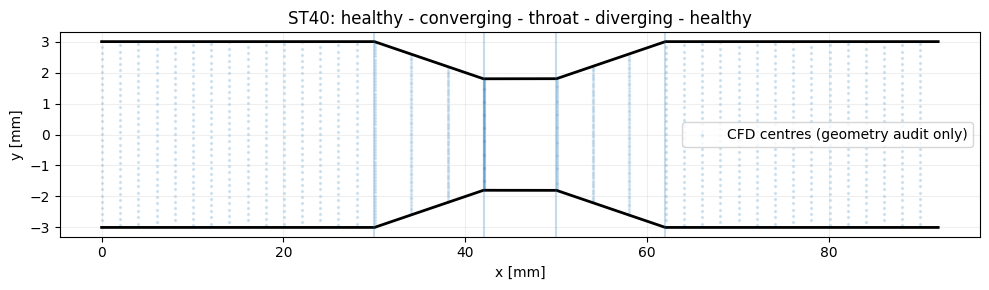

CFD solution arrays removed from memory. Training retains only metadata, geometry and inlet BC.


In [5]:
# Read-only CFD/reference audit. No solution value survives into training.
audit_case = load_planar_stenosis_case(ST40_DIR)
audit_summary = validate_planar_stenosis_case(audit_case)
metadata = json.loads(json.dumps(audit_case.metadata))
geometry = audit_case.geometry
inlet_y = audit_case.inlet_profile.y_m.copy()
inlet_u = audit_case.inlet_profile.u_m_s.copy()
inlet_v = audit_case.inlet_profile.v_m_s.copy()
mesh_table = pd.read_csv(ST40_DIR / "mesh_independence.csv")
profile_paths = sorted((ST40_DIR / "velocity_profiles").glob("profile_*.csv"))

assert audit_summary.n_field_points == 110_400
assert audit_summary.n_unique_coordinates == 110_400
assert audit_summary.n_streamwise_locations == 920
assert audit_summary.min_points_per_streamwise_location == 120
assert audit_summary.max_points_per_streamwise_location == 120
assert audit_summary.inlet_profile_points == 120 and len(profile_paths) == 5
assert abs(geometry.severity_percent - 40.0) < 0.1
assert mesh_table.loc[mesh_table["mesh"] == "fine", "medium_to_fine_throat_change_percent"].iloc[0] < 2.0

field_ranges = pd.DataFrame({
    "field": ["u", "v", "p", "viscosity"],
    "minimum": [audit_case.field.u_m_s.min(), audit_case.field.v_m_s.min(),
                audit_case.field.pressure_pa.min(), audit_case.field.viscosity_pa_s.min()],
    "maximum": [audit_case.field.u_m_s.max(), audit_case.field.v_m_s.max(),
                audit_case.field.pressure_pa.max(), audit_case.field.viscosity_pa_s.max()],
})
display(pd.DataFrame([audit_summary.__dict__]).T.rename(columns={0: "value"}))
display(field_ranges); display(mesh_table)

x_geom = np.linspace(0, geometry.total_length_m, 1200)
h_geom = geometry.half_height(x_geom)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x_geom*1e3, h_geom*1e3, "k", lw=2); ax.plot(x_geom*1e3, -h_geom*1e3, "k", lw=2)
ax.scatter(audit_case.field.x_m[::80]*1e3, audit_case.field.y_m[::80]*1e3, s=2, alpha=.15,
           label="CFD centres (geometry audit only)")
for x in (0.030, 0.042, 0.050, 0.062): ax.axvline(x*1e3, color="tab:blue", alpha=.25)
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="ST40: healthy - converging - throat - diverging - healthy")
ax.grid(alpha=.2); ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR/"figures"/"st40_geometry.png", dpi=170); plt.show()

# Remove all internal CFD solution arrays before model construction/training.
CFD_AUDIT_COMPLETE = True
del audit_case, field_ranges
gc.collect()
print("CFD solution arrays removed from memory. Training retains only metadata, geometry and inlet BC.")


## Method contract

Task 1.4 tests the trainer, not a new flow formulation. The model, hard boundary
transform, six mixed outputs, Carreau–Yasuda law, normalization and fixed physics
score are retained from Tasks 1.2–1.3. ST40 is deliberately used again because
it is the already validated reference case.

The prior Task 1.3 Fourier-OFF checkpoint is an input initialization only. It was
selected using physics residuals, not CFD labels. Adam and L-BFGS are both run in
this notebook, and the final result is selected only on a fixed physics set.


In [6]:
# Permitted physical inputs and dimensional residual scales.
rho = float(metadata["density_kg_m3"])
cy = metadata["bird_carreau"]
ETA0, ETA_INF = float(cy["mu0_Pa_s"]), float(cy["muInf_Pa_s"])
LAM, POWER_N, YASUDA_A = float(cy["lambda_s"]), float(cy["n"]), float(cy["a"])
L = float(geometry.total_length_m)
H = float(geometry.healthy_half_height_m)
HT = float(geometry.throat_half_height_m)
U = float(metadata["mean_inlet_velocity_m_s"])
V_SCALE = U * H / L
MU_REF = math.sqrt(ETA0 * ETA_INF)
P_SCALE = rho * U**2
TAU_SCALE = MU_REF * U / H
CONT_SCALE = U / L + V_SCALE / H
FORCE_SCALE = rho * U**2 / L + TAU_SCALE / H
Q_TARGET = 2.0 * H * U
physical = dict(rho=rho, mu0=ETA0, muInf=ETA_INF, lambda_s=LAM,
                n=POWER_N, a=YASUDA_A, L_m=L, H_m=H,
                throat_half_height_m=HT, U_m_s=U, V_scale=V_SCALE,
                pressure_scale_pa=P_SCALE, stress_scale_pa=TAU_SCALE,
                target_flow_m2_s=Q_TARGET)
display(pd.DataFrame([physical]).T.rename(columns={0: "value"}))


,value
rho,1060.000000
mu0,0.056000
muInf,0.003500
lambda_s,3.313000
n,0.356800
a,2.000000
L_m,0.092000
H_m,0.003000
throat_half_height_m,0.001800
U_m_s,0.275160


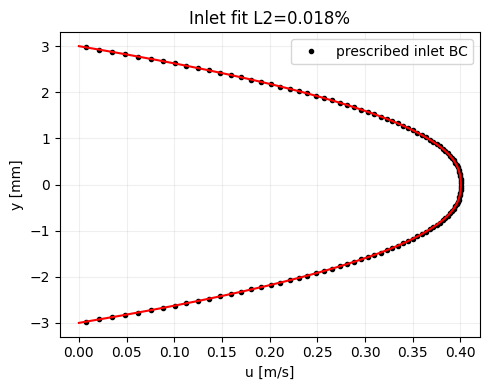

In [7]:
# High-accuracy representation of the prescribed inlet boundary condition.
from numpy.polynomial import chebyshev as cheb
inlet_eta = inlet_y / H
degree = 20
basis = cheb.chebvander(inlet_eta, degree) * (1.0 - inlet_eta**2)[:, None]
coefficients = np.linalg.lstsq(basis, inlet_u, rcond=None)[0]
u_coeff = cheb.chebmul(coefficients, np.array([0.5, 0.0, -0.5]))
integral = cheb.chebint(u_coeff)
raw_mean = 0.5 * (cheb.chebval(1.0, integral) - cheb.chebval(-1.0, integral))
u_coeff *= U / raw_mean
inlet_fit = cheb.chebval(inlet_eta, u_coeff)
inlet_fit_l2 = relative_l2_error(inlet_fit, inlet_u)
assert inlet_fit_l2 < 5e-3
assert abs(cheb.chebval(-1.0, u_coeff)) < 1e-10
assert abs(cheb.chebval(1.0, u_coeff)) < 1e-10
U_COEFFS = torch.tensor((u_coeff / U).astype(np.float32), device=device)

def cheb_eval(x, coefficients):
    b1, b2 = torch.zeros_like(x), torch.zeros_like(x)
    for coefficient in torch.flip(coefficients, dims=[0]):
        b2, b1 = b1, 2.0*x*b1 - b2 + coefficient
    return b1 - x*b2

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(inlet_u, inlet_y*1e3, "k.", label="prescribed inlet BC")
eta_plot = np.linspace(-1,1,401)
ax.plot(cheb.chebval(eta_plot,u_coeff), eta_plot*H*1e3, "r-")
ax.set(xlabel="u [m/s]", ylabel="y [mm]", title=f"Inlet fit L2={100*inlet_fit_l2:.3f}%")
ax.grid(alpha=.2); ax.legend(); fig.tight_layout(); plt.show()


In [8]:
# Exact geometry for hard constraints and a smooth geometry-aligned coordinate map.
X1,X2,X3,X4=.030,.042,.050,.062
CORNERS=torch.tensor([X1,X2,X3,X4],device=device,dtype=DTYPE);CORNER_GUARD=2.5e-4
def h_exact(x):
    h=torch.full_like(x,H)
    h=torch.where((x>=X1)&(x<X2),H+(HT-H)*(x-X1)/(X2-X1),h)
    h=torch.where((x>=X2)&(x<=X3),torch.full_like(h,HT),h)
    h=torch.where((x>X3)&(x<=X4),HT+(H-HT)*(x-X3)/(X4-X3),h)
    return h
SMOOTH_EPS=2e-5
def smooth_relu(z):return torch.nn.functional.softplus(z/SMOOTH_EPS)*SMOOTH_EPS
def h_smooth(x):
    down=(HT-H)/(X2-X1)*(smooth_relu(x-X1)-smooth_relu(x-X2))
    up=(H-HT)/(X4-X3)*(smooth_relu(x-X3)-smooth_relu(x-X4))
    return H+down+up
def hprime_exact(x):
    slope=torch.zeros_like(x)
    slope=torch.where((x>=X1)&(x<X2),(HT-H)/(X2-X1),slope)
    slope=torch.where((x>X3)&(x<=X4),(H-HT)/(X4-X3),slope)
    return slope
def corner_safe(x):return (x.reshape(-1,1)-CORNERS.reshape(1,-1)).abs().min(1).values>CORNER_GUARD


In [9]:
# Task 1.3 finalized architecture, with Fourier deliberately OFF for ST40.
class StenosisMixedModel(nn.Module):
    def __init__(self, core):
        super().__init__(); self.core = core
    def forward(self, xy):
        x, y = xy[:, :1], xy[:, 1:2]
        he = h_exact(x); eta = y / he
        coordinates = torch.cat((2*x/L - 1, y/h_smooth(x)), dim=1)
        raw = self.core(coordinates)
        s = x/L; wall = 1 - eta.square(); ramp = 1 - torch.exp(-x/(.08*L))
        base = U*(H/he)*cheb_eval(eta, U_COEFFS)
        u = base + ramp*wall*U*raw[:, :1]
        v = ramp*wall*V_SCALE*raw[:, 1:2]
        p = (1-s)*P_SCALE*raw[:, 2:3]
        return torch.cat((u, v, p, TAU_SCALE*raw[:, 3:6]), dim=1)

def build_model():
    core = BloodFlowPINN(
        in_dim=2, out_dim=6, hidden_layers=5, hidden_width=128,
        fourier_enabled=False, zero_output=True,
    )
    return StenosisMixedModel(core).to(device=device, dtype=DTYPE)

torch.manual_seed(SEED + 13)
model = build_model()
assert not model.core.fourier_enabled
print(model)
print("parameters:", sum(parameter.numel() for parameter in model.parameters()))
print("outputs: u, v, p, tau_xx, tau_xy, tau_yy | Fourier: OFF")


StenosisMixedModel(
  (core): BloodFlowPINN(
    (encoder): FourierFeatureEncoding(in_dim=2, num_frequencies=20, frequency_scale=1.0, seed=20260918, enabled=False, include_input=True)
    (network): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): Tanh()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): Tanh()
      (6): Linear(in_features=128, out_features=128, bias=True)
      (7): Tanh()
      (8): Linear(in_features=128, out_features=128, bias=True)
      (9): Tanh()
      (10): Linear(in_features=128, out_features=6, bias=True)
    )
  )
)
parameters: 67206
outputs: u, v, p, tau_xx, tau_xy, tau_yy | Fourier: OFF


In [12]:
# Required Task 1.3 physics-only initialization.

TASK13_CHECKPOINT_OVERRIDE = (
    "/kaggle/input/datasets/nightfury22344/"
    "rheolnet-task1-3-residual-fourier-checkpoints/"
    "task_1_3_fourier_residual_ab/checkpoints/fourier_off_best.pt"
)

if TASK13_CHECKPOINT_OVERRIDE:
    candidates = [Path(TASK13_CHECKPOINT_OVERRIDE)]
else:
    candidates = sorted(
        Path("/kaggle/input").glob("**/fourier_off_best.pt")
    )

    local_candidate = Path(
        "/kaggle/working/task_1_3_fourier_residual_ab/"
        "checkpoints/fourier_off_best.pt"
    )

    if local_candidate.is_file():
        candidates.append(local_candidate)

if not candidates:
    raise FileNotFoundError(
        "Task 1.3 Fourier-OFF checkpoint was not found."
    )

if len(candidates) > 1 and not TASK13_CHECKPOINT_OVERRIDE:
    print("Multiple candidates found:")
    for candidate in candidates:
        print(" -", candidate)

    raise RuntimeError(
        "Set TASK13_CHECKPOINT_OVERRIDE to the intended checkpoint."
    )

TASK13_CHECKPOINT = candidates[0]

task13_payload = torch.load(
    TASK13_CHECKPOINT,
    map_location=device,
    weights_only=False,
)

assert task13_payload.get("variant") == "fourier_off"
assert task13_payload.get("used_cfd_labels_for_training") is False
assert task13_payload.get("gate_profiles_used") is False

checkpoint_state = task13_payload["model"]


# Exact architecture used by the residual-Fourier OFF checkpoint.
class Task13ResidualOffCore(nn.Module):
    def __init__(
        self,
        out_dim=6,
        width=128,
        depth=5,
    ):
        super().__init__()

        self.out_dim = out_dim
        self.fourier_enabled = False

        self.raw_input = nn.Linear(2, width)
        nn.init.xavier_normal_(self.raw_input.weight)
        nn.init.zeros_(self.raw_input.bias)

        # These attributes preserve the Task 1.3 residual-model interface.
        self.encoder = None
        self.fourier_input = None

        self.register_buffer(
            "fourier_weight",
            torch.tensor(0.0, dtype=torch.float32),
            persistent=True,
        )

        self.hidden = nn.ModuleList()

        for _ in range(depth - 1):
            layer = nn.Linear(width, width)
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
            self.hidden.append(layer)

        self.output = nn.Linear(width, out_dim)
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, coordinates):
        hidden = torch.tanh(self.raw_input(coordinates))

        for layer in self.hidden:
            hidden = torch.tanh(layer(hidden))

        return self.output(hidden)


# Redefine build_model so the later fresh-checkpoint reload uses
# exactly the same architecture.
def build_model():
    core = Task13ResidualOffCore(
        out_dim=6,
        width=128,
        depth=5,
    )

    return StenosisMixedModel(core).to(
        device=device,
        dtype=DTYPE,
    )


# Rebuild and load the exact checkpoint architecture.
model = build_model()

model.load_state_dict(
    checkpoint_state,
    strict=True,
)

TASK13_START_SCORE = float(task13_payload["physics_score"])
TASK13_FINGERPRINT = task13_payload["fingerprint"]

del task13_payload
gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

print(
    "Loaded Task 1.3 Fourier-OFF physics checkpoint:",
    TASK13_CHECKPOINT,
)
print("Task 1.3 fixed score:", TASK13_START_SCORE)
print("Checkpoint architecture compatibility: PASS")

Loaded Task 1.3 Fourier-OFF physics checkpoint: /kaggle/input/datasets/nightfury22344/rheolnet-task1-3-residual-fourier-checkpoints/task_1_3_fourier_residual_ab/checkpoints/fourier_off_best.pt
Task 1.3 fixed score: 0.5045697745401412
Checkpoint architecture compatibility: PASS


In [13]:
# Deterministic shared point generation for a fair paired experiment.
def make_generator(seed):
    generator=torch.Generator(device=device);generator.manual_seed(seed);return generator
TRAIN_GENERATOR=make_generator(SEED+101)
def region_points(n,generator):
    chunks=[];remaining=int(n)
    while remaining:
        m=max(2*remaining,512);ng=int(.30*m);nl=int(.45*m);nt=m-ng-nl
        x=torch.cat((L*torch.rand((ng,1),device=device,generator=generator),
            .026+.040*torch.rand((nl,1),device=device,generator=generator),
            .038+.016*torch.rand((nt,1),device=device,generator=generator)),dim=0)
        x=x[corner_safe(x[:,0])];take=min(remaining,len(x));chunks.append(x[:take]);remaining-=take
    x=torch.cat(chunks);uniform=2*torch.rand(x.shape,device=device,generator=generator)-1
    z=torch.rand(x.shape,device=device,generator=generator)
    sign=torch.where(torch.rand(x.shape,device=device,generator=generator)<.5,-torch.ones_like(x),torch.ones_like(x))
    eta=torch.where(torch.rand(x.shape,device=device,generator=generator)<.4,sign*(1-z.pow(3)),uniform).clamp(-.995,.995)
    return torch.cat((x,eta*h_exact(x)),dim=1)
def global_points(n,generator):
    chunks=[];remaining=n
    while remaining:
        m=max(2*remaining,512);x=L*torch.rand((m,1),device=device,generator=generator);x=x[corner_safe(x[:,0])]
        take=min(remaining,len(x));chunks.append(x[:take]);remaining-=take
    x=torch.cat(chunks);eta=2*torch.rand(x.shape,device=device,generator=generator)-1
    return torch.cat((x,eta*h_exact(x)),1)
wall_bottom,wall_top=sample_wall_points(geometry,1200,device=device,dtype=DTYPE)
INLET_XY=sample_inlet_points(geometry,601,device=device,dtype=DTYPE)
OUTLET_XY=sample_outlet_points(geometry,401,device=device,dtype=DTYPE)
INLET_TARGET=torch.cat((U*cheb_eval(INLET_XY[:,1:2]/H,U_COEFFS),torch.zeros((601,1),device=device)),1)
def boundary_batch(n,generator):
    ids=torch.randint(len(wall_top),(n,),device=device,generator=generator)
    inlet_ids=torch.randint(len(INLET_XY),(n,),device=device,generator=generator)
    outlet_ids=torch.randint(len(OUTLET_XY),(n,),device=device,generator=generator)
    centre_x=region_points(n,generator)[:,:1]
    return dict(top=wall_top[ids],bottom=wall_bottom[ids],inlet=INLET_XY[inlet_ids],
                outlet=OUTLET_XY[outlet_ids],centre=torch.cat((centre_x,torch.zeros_like(centre_x)),1))
FIXED_GENERATOR=make_generator(SEED+909)
FIXED_DIAGNOSTIC=torch.cat((global_points(2048,FIXED_GENERATOR),region_points(2048,FIXED_GENERATOR)))
print("shared fixed diagnostic:",tuple(FIXED_DIAGNOSTIC.shape))


shared fixed diagnostic: (4096, 2)


In [14]:
# Shared first-order mixed Carreau-Yasuda residual operator.
def derivative(value,xy):return torch.autograd.grad(value,xy,torch.ones_like(value),create_graph=True,retain_graph=True)[0]
def carreau_yasuda(shear):return ETA_INF+(ETA0-ETA_INF)*(1+(LAM*shear).square()).pow((POWER_N-1)/YASUDA_A)
def mixed_residuals(net,points,inertia=1.):
    xy=points.detach().clone().requires_grad_(True);out=net(xy)
    u,v,p,txx,txy,tyy=[out[:,i:i+1] for i in range(6)]
    gu,gv,gp=derivative(u,xy),derivative(v,xy),derivative(p,xy)
    gxx,gxy,gyy=derivative(txx,xy),derivative(txy,xy),derivative(tyy,xy)
    ux,uy=gu[:,:1],gu[:,1:2];vx,vy=gv[:,:1],gv[:,1:2]
    shear=torch.sqrt((2*ux.square()+2*vy.square()+(uy+vx).square()).clamp_min(1e-16));mu=carreau_yasuda(shear)
    residuals=dict(continuity=(ux+vy)/CONT_SCALE,
        momentum_x=(rho*inertia*(u*ux+v*uy)+gp[:,:1]-gxx[:,:1]-gxy[:,1:2])/FORCE_SCALE,
        momentum_y=(rho*inertia*(u*vx+v*vy)+gp[:,1:2]-gxy[:,:1]-gyy[:,1:2])/FORCE_SCALE,
        constitutive_xx=(txx-2*mu*ux)/TAU_SCALE,
        constitutive_xy=(txy-mu*(uy+vx))/TAU_SCALE,
        constitutive_yy=(tyy-2*mu*vy)/TAU_SCALE)
    return residuals,mu,shear
PDE_NAMES=("continuity","momentum_x","momentum_y","constitutive_xx","constitutive_xy","constitutive_yy")


In [15]:
# Identical auxiliary physics for both variants.
MASS_X=torch.linspace(.004,L-.004,21,device=device);MASS_X=MASS_X[corner_safe(MASS_X)].reshape(-1,1)
MASS_ETA=torch.linspace(-1,1,81,device=device).reshape(1,-1,1)
def flux_loss(net):
    x=MASS_X.reshape(-1,1,1);xg=x.expand(-1,MASS_ETA.shape[1],-1);yg=MASS_ETA*h_exact(xg)
    points=torch.cat((xg,yg),-1).reshape(-1,2);u=net(points)[:,0].reshape(len(MASS_X),-1)
    q=torch.trapz(u,yg.squeeze(-1),dim=1);return ((q/Q_TARGET-1).square()).mean()
def boundary_losses(net,batch):
    top=batch["top"].detach().clone().requires_grad_(True);bottom=batch["bottom"].detach().clone().requires_grad_(True)
    inlet=batch["inlet"].detach().clone().requires_grad_(True);outlet=batch["outlet"].detach().clone().requires_grad_(True)
    centre=batch["centre"].detach().clone().requires_grad_(True)
    gpt=derivative(net(top)[:,2:3],top);gpb=derivative(net(bottom)[:,2:3],bottom);gpi=derivative(net(inlet)[:,2:3],inlet)
    pn_t=(-hprime_exact(top[:,:1])*gpt[:,:1]+gpt[:,1:2])/(P_SCALE/H)
    pn_b=(-hprime_exact(bottom[:,:1])*gpb[:,:1]-gpb[:,1:2])/(P_SCALE/H)
    pn_i=gpi[:,:1]/(P_SCALE/L);out=net(outlet);go_u=derivative(out[:,:1],outlet);go_v=derivative(out[:,1:2],outlet)
    c=net(centre);gc_u=derivative(c[:,:1],centre)
    return dict(pressure_neumann=(pn_t.square().mean()+pn_b.square().mean()+pn_i.square().mean())/3,
        outflow=(L*go_u[:,:1]/U).square().mean()+(L*go_v[:,:1]/V_SCALE).square().mean(),
        symmetry=(c[:,1:2]/V_SCALE).square().mean()+(H*gc_u[:,1:2]/U).square().mean())
def exact_boundary_audit(net):
    with torch.no_grad():
        wall_uv=net(torch.cat((wall_top,wall_bottom)))[:,:2].abs().max()
        inlet_error=(net(INLET_XY)[:,:2]-INLET_TARGET).abs().max();outlet_p=net(OUTLET_XY)[:,2].abs().max()
    return dict(wall_uv_max=float(wall_uv),inlet_uv_max=float(inlet_error),outlet_p_max=float(outlet_p))


In [16]:
# Adaptive physics weights. State is included in every trainer checkpoint.
BASE_WEIGHTS = dict(continuity=3., momentum_x=3., momentum_y=1.5,
                    constitutive_xx=1., constitutive_xy=1.5, constitutive_yy=1.)
AUX_WEIGHTS = dict(flux=10., outflow=.75, symmetry=.5, pressure_neumann=.2)

class EMABalancer:
    def __init__(self, decay=.98): self.decay=decay; self.ema={}; self.steps=0
    def weights(self, terms, update=True):
        values={name:max(float(terms[name].detach()),1e-10) for name in PDE_NAMES}
        if update:
            for name,value in values.items():
                self.ema[name]=value if name not in self.ema else self.decay*self.ema[name]+(1-self.decay)*value
            self.steps += 1
        if not self.ema: raise RuntimeError("Adaptive weights have not been initialized")
        scale=np.exp(np.mean(np.log(list(self.ema.values())))); result={}
        for name in PDE_NAMES:
            base=BASE_WEIGHTS[name]
            proposed=base*math.sqrt(scale/max(self.ema[name],1e-10))
            result[name]=min(4*base,max(.35*base,proposed))
        return result
    def state_dict(self): return dict(decay=self.decay,ema=self.ema,steps=self.steps)
    def load_state_dict(self,state):
        self.decay=float(state["decay"]); self.ema=dict(state["ema"]); self.steps=int(state["steps"])

balancer = EMABalancer()

def trainer_loss(net, batch, phase, update_balance):
    inertia=float(phase.get("inertia",1.0)); pde_factor=float(phase.get("pde_factor",1.0))
    residuals,_,_=mixed_residuals(net,batch["points"],inertia)
    terms={name:residuals[name].square().mean() for name in PDE_NAMES}
    terms["flux"]=flux_loss(net)
    terms.update(boundary_losses(net,batch["boundary"]))
    weights=balancer.weights(terms,update=update_balance)
    total=sum(pde_factor*weights[name]*terms[name] for name in PDE_NAMES)
    total+=sum(AUX_WEIGHTS[name]*terms[name] for name in AUX_WEIGHTS)
    return total,terms,weights

def task14_batch_sampler(phase, step):
    points=region_points(int(phase["batch_size"]),TRAIN_GENERATOR)
    permutation=torch.randperm(len(points),device=device,generator=TRAIN_GENERATOR)
    return {"points":points[permutation],"boundary":boundary_batch(256,TRAIN_GENERATOR)}


In [17]:
# One held-fixed physics set drives checkpoint selection; no CFD values are used.
def diagnostic(net):
    flags=[parameter.requires_grad for parameter in net.parameters()]
    for parameter in net.parameters(): parameter.requires_grad_(False)
    try:
        residuals,mu,_=mixed_residuals(net,FIXED_DIAGNOSTIC,1.0)
        result={name+"_rms":float(torch.sqrt(residuals[name].square().mean()).detach()) for name in PDE_NAMES}
        result["flux_rms"]=float(torch.sqrt(flux_loss(net)).detach())
        result["viscosity_min"]=float(mu.min().detach()); result["viscosity_max"]=float(mu.max().detach())
    finally:
        for parameter,flag in zip(net.parameters(),flags): parameter.requires_grad_(flag)
    result["fixed_pde_score"]=(result["continuity_rms"]+result["momentum_x_rms"]+result["momentum_y_rms"]
        +.35*(result["constitutive_xx_rms"]+result["constitutive_xy_rms"]+result["constitutive_yy_rms"])
        +2*result["flux_rms"])
    return result

initial_diagnostic=diagnostic(model)
print(json.dumps(initial_diagnostic,indent=2))
assert np.isfinite(list(initial_diagnostic.values())).all()
assert abs(initial_diagnostic["fixed_pde_score"]-TASK13_START_SCORE)<1e-5
print("Task 1.3 checkpoint reproduction: PASS")


{
  "continuity_rms": 0.153387188911438,
  "momentum_x_rms": 0.11037774384021759,
  "momentum_y_rms": 0.03606557846069336,
  "constitutive_xx_rms": 0.010086203925311565,
  "constitutive_xy_rms": 0.3300246000289917,
  "constitutive_yy_rms": 0.010168615728616714,
  "flux_rms": 0.04107073321938515,
  "viscosity_min": 0.003805622924119234,
  "viscosity_max": 0.03495655581355095,
  "fixed_pde_score": 0.5045697745401412
}
Task 1.3 checkpoint reproduction: PASS


In [18]:
# Optional Weights & Biases logging. The notebook is fully functional when False.
USE_WANDB = False
wandb_run = None
if USE_WANDB:
    try:
        import wandb
    except ModuleNotFoundError as error:
        raise ModuleNotFoundError("Enable Kaggle internet and install/login to wandb, or set USE_WANDB=False") from error
    wandb_run=wandb.init(project="RheolNet",name="task-1-4-adam-lbfgs-st40",config={"seed":SEED,"commit":COMMIT})

def notebook_logger(row):
    if wandb_run is not None: wandb_run.log(dict(row))
    phase=row.get("optimizer_phase")
    if phase=="adam":
        print(f"Adam {row['phase']} {row['step']:5d} | loss={row['total']:.4g} | "
              f"lr={row['learning_rate']:.2e} | {row['seconds_per_step']:.3f} s/step")
    elif phase=="lbfgs_summary":
        print(f"L-BFGS closures={row['closure_calls']} | candidate={row['candidate_score']:.6g} | "
              f"accepted={row['accepted']}")

print("W&B:","enabled" if USE_WANDB else "disabled (local JSON logging remains active)")


W&B: disabled (local JSON logging remains active)


In [19]:
# T4 schedule. QUICK_MODE is only a smoke test and cannot complete the task.
QUICK_MODE=os.getenv("RHEOLNET_QUICK_MODE","0")=="1"
ADAM_PHASES=[
    AdamPhase(name="adam_stabilize",steps=600,learning_rate=1.0e-4,batch_size=2048,
              inertia=1.0,pde_factor=1.0,report_every=100,diagnostic_every=200,checkpoint_every=300),
    AdamPhase(name="adam_physical",steps=1800,learning_rate=8.0e-5,batch_size=3584,
              inertia=1.0,pde_factor=1.0,report_every=100,diagnostic_every=200,checkpoint_every=400),
]
LBFGS_CONFIG=LBFGSPhase(name="lbfgs_fixed_refinement",max_iterations=140,
    learning_rate=.6,history_size=25,tolerance_grad=1e-8,tolerance_change=1e-10,
    line_search_fn="strong_wolfe",grad_clip=None)
if QUICK_MODE:
    ADAM_PHASES=[AdamPhase(name="adam_smoke",steps=3,learning_rate=1e-4,batch_size=256,
                           report_every=1,diagnostic_every=1,checkpoint_every=2)]
    LBFGS_CONFIG=LBFGSPhase(name="lbfgs_smoke",max_iterations=3,history_size=3)

TRAINER_CONFIG=dict(task="1.4",case="P2D_ST40_Re500",architecture="5x128 mixed six-output Fourier OFF",
    initialization="Task 1.3 Fourier-OFF physics checkpoint",task13_fingerprint=TASK13_FINGERPRINT,
    adam=[phase.__dict__ for phase in ADAM_PHASES],lbfgs=LBFGS_CONFIG.__dict__,
    adaptive_weights="bounded EMA",fixed_selection_points=len(FIXED_DIAGNOSTIC),
    amp=False,float32_derivatives=True,used_cfd_labels_for_training=False,
    seed=SEED,git_commit=COMMIT,quick_mode=QUICK_MODE)
print(json.dumps(TRAINER_CONFIG,indent=2,default=str))


{
  "task": "1.4",
  "case": "P2D_ST40_Re500",
  "architecture": "5x128 mixed six-output Fourier OFF",
  "initialization": "Task 1.3 Fourier-OFF physics checkpoint",
  "task13_fingerprint": "8a182c9fb77e95c4",
  "adam": [
    {
      "name": "adam_stabilize",
      "steps": 600,
      "learning_rate": 0.0001,
      "batch_size": 2048,
      "inertia": 1.0,
      "pde_factor": 1.0,
      "weight_decay": 1e-08,
      "warmup_fraction": 0.04,
      "minimum_lr_fraction": 0.05,
      "grad_clip": 2.0,
      "report_every": 100,
      "diagnostic_every": 200,
      "checkpoint_every": 300
    },
    {
      "name": "adam_physical",
      "steps": 1800,
      "learning_rate": 8e-05,
      "batch_size": 3584,
      "inertia": 1.0,
      "pde_factor": 1.0,
      "weight_decay": 1e-08,
      "warmup_fraction": 0.04,
      "minimum_lr_fraction": 0.05,
      "grad_clip": 2.0,
      "report_every": 100,
      "diagnostic_every": 200,
      "checkpoint_every": 400
    }
  ],
  "lbfgs": {
    "name"

In [20]:
# Preflight the exact training and checkpoint interfaces.
pre_batch=task14_batch_sampler(ADAM_PHASES[0].__dict__,0)
pre_total,pre_terms,pre_weights=trainer_loss(model,pre_batch,ADAM_PHASES[0].__dict__,True)
assert torch.isfinite(pre_total)
assert set(pre_terms)==set(PDE_NAMES)|set(AUX_WEIGHTS)
assert max(exact_boundary_audit(model).values())<2e-5
assert all(np.isfinite(list(pre_weights.values())))
print("preflight loss:",float(pre_total.detach()))
print("hard boundary audit:",exact_boundary_audit(model))
print("TASK 1.4 PREFLIGHT: PASS")


preflight loss: 0.12388499081134796
hard boundary audit: {'wall_uv_max': 0.0, 'inlet_uv_max': 1.043081283569336e-07, 'outlet_p_max': 0.0}
TASK 1.4 PREFLIGHT: PASS


In [21]:
# Build the reusable trainer. RESUME=True safely continues an interrupted Adam run.
TRAINING_DIR=OUTPUT_DIR/"trainer"
trainer=PINNTrainer(model=model,loss_fn=trainer_loss,batch_sampler=task14_batch_sampler,
    diagnostic_fn=diagnostic,output_dir=TRAINING_DIR,config=TRAINER_CONFIG,device=device,
    stateful={"adaptive_loss_balancer":balancer},metric_logger=notebook_logger,
    selection_key="fixed_pde_score")
print("trainer fingerprint:",trainer.fingerprint)
print("checkpoint directory:",TRAINING_DIR)


trainer fingerprint: 37af9f385b0ce910
checkpoint directory: /kaggle/working/task_1_4_adam_lbfgs/trainer


In [22]:
# Phase 1: resampled AdamW + warm-up/cosine schedule + gradient clipping.
RUN_ADAM=True; RESUME_ADAM=True
if RUN_ADAM:
    history,adam_best_score=trainer.train_adam(ADAM_PHASES,resume=RESUME_ADAM)
else:
    trainer.restore(TRAINING_DIR/"best_adam_checkpoint.pt")
    history=trainer.history; adam_best_score=trainer.best_score
adam_payload=load_torch_checkpoint(TRAINING_DIR/"best_adam_checkpoint.pt",map_location=device)
assert adam_payload["adam_completed"] is True
assert adam_payload["optimizer"] is not None and adam_payload["scheduler"] is not None
print("best Adam fixed score:",adam_best_score)
print("Adam checkpoint:",trainer.adam_checkpoint)


Adam adam_stabilize     0 | loss=0.1271 | lr=8.33e-06 | 0.400 s/step
Adam adam_stabilize   100 | loss=0.1223 | lr=9.59e-05 | 0.197 s/step
Adam adam_stabilize   200 | loss=0.1181 | lr=7.95e-05 | 0.195 s/step
Adam adam_stabilize   300 | loss=0.113 | lr=5.52e-05 | 0.194 s/step
Adam adam_stabilize   400 | loss=0.1102 | lr=3.02e-05 | 0.194 s/step
Adam adam_stabilize   500 | loss=0.1096 | lr=1.16e-05 | 0.194 s/step
Adam adam_stabilize   599 | loss=0.109 | lr=5.00e-06 | 0.191 s/step
Adam adam_physical     0 | loss=0.1111 | lr=2.22e-06 | 0.198 s/step
Adam adam_physical   100 | loss=0.1118 | lr=7.99e-05 | 0.193 s/step
Adam adam_physical   200 | loss=0.1086 | lr=7.90e-05 | 0.194 s/step
Adam adam_physical   300 | loss=0.1029 | lr=7.68e-05 | 0.196 s/step
Adam adam_physical   400 | loss=0.1047 | lr=7.34e-05 | 0.193 s/step
Adam adam_physical   500 | loss=0.1042 | lr=6.90e-05 | 0.197 s/step
Adam adam_physical   600 | loss=0.1055 | lr=6.37e-05 | 0.194 s/step
Adam adam_physical   700 | loss=0.09995 | l

In [23]:
# Phase 2 uses one deterministic batch. Adaptive weights update once, then freeze
# across every repeated L-BFGS closure evaluation. AMP is explicitly disabled.
LBFGS_GENERATOR=make_generator(SEED+1414)
LBFGS_FIXED_BATCH={
    "points":torch.cat((global_points(1536,LBFGS_GENERATOR),region_points(1536,LBFGS_GENERATOR))),
    "boundary":boundary_batch(256,LBFGS_GENERATOR),
}
RUN_LBFGS=True
if RUN_LBFGS:
    history,final_best_score=trainer.refine_lbfgs(
        LBFGS_CONFIG,fixed_batch=LBFGS_FIXED_BATCH,restore_best_adam=True)
else:
    trainer.restore(TRAINING_DIR/"final_lbfgs_checkpoint.pt")
    history=trainer.history; final_best_score=trainer.best_score
lbfgs_payload=load_torch_checkpoint(TRAINING_DIR/"final_lbfgs_checkpoint.pt",map_location=device)
print("Adam best:",adam_best_score)
print("L-BFGS candidate:",lbfgs_payload["lbfgs_candidate_score"])
print("selected final:",final_best_score)
print("L-BFGS accepted:",lbfgs_payload["lbfgs_accepted"])


L-BFGS closures=145 | candidate=0.648615 | accepted=False
Adam best: 0.42042376534081993
L-BFGS candidate: 0.6486147351097316
selected final: 0.42042376534081993
L-BFGS accepted: False


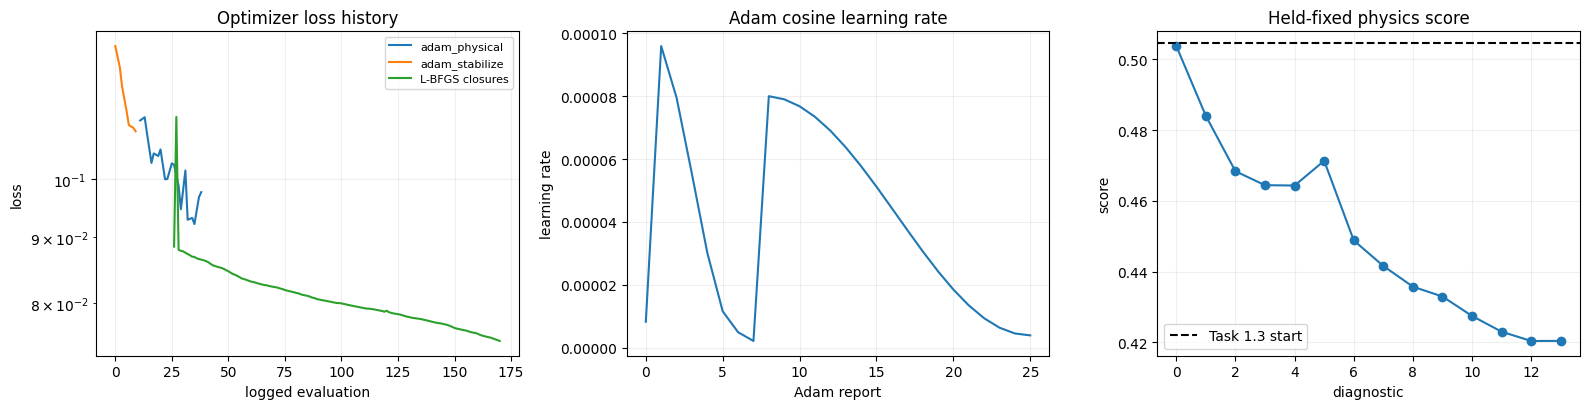

,optimizer_phase,phase,phase_index,step,total,learning_rate,grad_norm,seconds_per_step,continuity,momentum_x,...,constitutive_yy_rms,flux_rms,viscosity_min,viscosity_max,fixed_pde_score,closure_call,closure_calls,elapsed_seconds,candidate_score,accepted
27,diagnostic,adam_physical,1.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009661,0.028761,0.003792,0.027559,0.432981,NaN,NaN,NaN,NaN,NaN
30,diagnostic,adam_physical,1.0,1200.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009624,0.027453,0.003791,0.027684,0.427488,NaN,NaN,NaN,NaN,NaN
32,adam,adam_physical,1.0,1400.0,0.092915,0.000014,2.003761,0.194051,0.019234,0.008447,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,diagnostic,adam_physical,1.0,1400.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009573,0.027270,0.003791,0.026359,0.423037,NaN,NaN,NaN,NaN,NaN
34,adam,adam_physical,1.0,1500.0,0.093218,0.000009,1.074967,0.195665,0.019672,0.007928,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,adam,adam_physical,1.0,1600.0,0.092190,0.000006,2.152930,0.195269,0.018864,0.008525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,diagnostic,adam_physical,1.0,1600.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009611,0.027209,0.003790,0.026128,0.420424,NaN,NaN,NaN,NaN,NaN
37,adam,adam_physical,1.0,1700.0,0.096783,0.000005,1.013082,0.195231,0.021565,0.008545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,adam,adam_physical,1.0,1799.0,0.097655,0.000004,1.060797,0.196134,0.020722,0.008620,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,diagnostic,adam_physical,1.0,1799.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009621,0.027231,0.003790,0.026306,0.420448,NaN,NaN,NaN,NaN,NaN


In [24]:
# Loss, schedule and fixed-score evidence.
history_table=pd.DataFrame(history)
adam_rows=history_table[history_table["optimizer_phase"]=="adam"].copy()
lbfgs_rows=history_table[history_table["optimizer_phase"]=="lbfgs"].copy()
diagnostic_rows=history_table[history_table["optimizer_phase"]=="diagnostic"].copy()
fig,axes=plt.subplots(1,3,figsize=(16,4.2))
for phase,group in adam_rows.groupby("phase"):
    axes[0].semilogy(group["total"].clip(lower=1e-12),label=phase)
if len(lbfgs_rows): axes[0].semilogy(np.arange(len(lbfgs_rows))+len(adam_rows),lbfgs_rows["total"].clip(lower=1e-12),label="L-BFGS closures")
axes[0].set(title="Optimizer loss history",xlabel="logged evaluation",ylabel="loss");axes[0].legend(fontsize=8);axes[0].grid(alpha=.2)
axes[1].plot(adam_rows["learning_rate"].to_numpy());axes[1].set(title="Adam cosine learning rate",xlabel="Adam report",ylabel="learning rate");axes[1].grid(alpha=.2)
axes[2].plot(diagnostic_rows["fixed_pde_score"].to_numpy(),"o-");axes[2].axhline(TASK13_START_SCORE,color="k",ls="--",label="Task 1.3 start")
axes[2].set(title="Held-fixed physics score",xlabel="diagnostic",ylabel="score");axes[2].legend();axes[2].grid(alpha=.2)
fig.tight_layout();LOSS_CURVE_PATH=OUTPUT_DIR/"figures"/"task_1_4_training_curves.png"
fig.savefig(LOSS_CURVE_PATH,dpi=180);plt.show()
display(history_table.groupby("optimizer_phase").tail(5))


In [25]:
# Fresh-instance restore test: model output and fixed score must reproduce exactly.
probe_generator=make_generator(SEED+1515); RELOAD_PROBE=global_points(257,probe_generator)
model.eval()
with torch.no_grad(): expected_prediction=model(RELOAD_PROBE).detach().clone()

torch.manual_seed(SEED+999)
reloaded_model=build_model(); reloaded_balancer=EMABalancer()
original_balancer=balancer
balancer=reloaded_balancer  # trainer_loss closes over this name
reload_trainer=PINNTrainer(model=reloaded_model,loss_fn=trainer_loss,batch_sampler=task14_batch_sampler,
    diagnostic_fn=diagnostic,output_dir=OUTPUT_DIR/"reload_audit",config=TRAINER_CONFIG,device=device,
    stateful={"adaptive_loss_balancer":reloaded_balancer},selection_key="fixed_pde_score")
reload_payload=reload_trainer.restore(TRAINING_DIR/"final_lbfgs_checkpoint.pt")
reloaded_model.eval()
with torch.no_grad(): restored_prediction=reloaded_model(RELOAD_PROBE)
max_reload_difference=float((expected_prediction-restored_prediction).abs().max())
restored_diagnostic=diagnostic(reloaded_model)
balancer=original_balancer
assert max_reload_difference==0.0
assert abs(restored_diagnostic["fixed_pde_score"]-final_best_score)<1e-7
assert reload_payload["lbfgs_completed"] is True
print("maximum prediction difference after fresh reload:",max_reload_difference)
print("restored fixed score:",restored_diagnostic["fixed_pde_score"])
print("CHECKPOINT RESTORE: PASS")


maximum prediction difference after fresh reload: 0.0
restored fixed score: 0.42042376534081993
CHECKPOINT RESTORE: PASS


In [26]:
# Freeze before any CFD solution is loaded for the secondary regression check.
model=reloaded_model
for parameter in model.parameters(): parameter.requires_grad_(False)
model.eval(); MODEL_FROZEN=True
print("FINAL MODEL FROZEN - CFD validation may now begin")


FINAL MODEL FROZEN - CFD validation may now begin


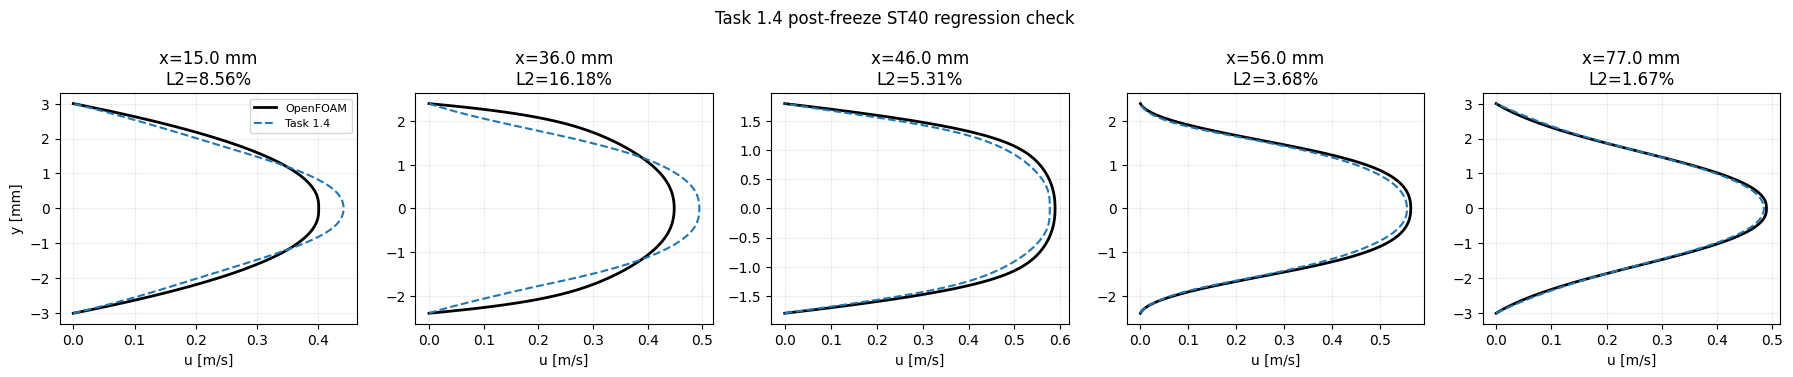

,profile,x_m,u_relative_l2_percent
0,profile_x015.csv,0.015,8.558375
1,profile_x036.csv,0.036,16.176916
2,profile_x046.csv,0.046,5.310195
3,profile_x056.csv,0.056,3.681718
4,profile_x077.csv,0.077,1.673409


{
  "mean_percent": 7.080122445466574,
  "maximum_percent": 16.176915637259672,
  "combined_percent": 8.330950461838066
}


In [27]:
# Secondary five-profile check. These values never affect training or selection.
assert MODEL_FROZEN
validation_case=load_planar_stenosis_case(ST40_DIR)
validation_profiles=[pd.read_csv(path) for path in profile_paths]
def predict(net,xy_np,chunk=8192):
    outputs=[]
    with torch.no_grad():
        for start in range(0,len(xy_np),chunk):
            outputs.append(net(torch.tensor(xy_np[start:start+chunk],device=device,dtype=DTYPE)).cpu().numpy())
    return np.concatenate(outputs)
rows=[];combined_prediction=[];combined_reference=[];fig,axes=plt.subplots(1,5,figsize=(18,3.8))
for ax,path,profile in zip(axes,profile_paths,validation_profiles):
    xy=profile[["x","y"]].to_numpy(np.float32);reference_u=profile["u"].to_numpy();x=float(profile["x"].median())
    prediction=predict(model,xy)[:,0];error=100*relative_l2_error(prediction,reference_u)
    rows.append(dict(profile=path.name,x_m=x,u_relative_l2_percent=error))
    combined_prediction.append(prediction);combined_reference.append(reference_u)
    ax.plot(reference_u,profile["y"]*1e3,"k-",lw=2,label="OpenFOAM")
    ax.plot(prediction,profile["y"]*1e3,"tab:blue",ls="--",label="Task 1.4")
    ax.set(xlabel="u [m/s]",title=f"x={1e3*x:.1f} mm\nL2={error:.2f}%");ax.grid(alpha=.2)
axes[0].set_ylabel("y [mm]");axes[0].legend(fontsize=8);fig.suptitle("Task 1.4 post-freeze ST40 regression check")
fig.tight_layout();PROFILE_FIGURE_PATH=OUTPUT_DIR/"figures"/"task_1_4_profiles.png"
fig.savefig(PROFILE_FIGURE_PATH,dpi=180,bbox_inches="tight");plt.show()
profile_table=pd.DataFrame(rows);display(profile_table)
cfd_summary=dict(mean_percent=float(profile_table.u_relative_l2_percent.mean()),
    maximum_percent=float(profile_table.u_relative_l2_percent.max()),
    combined_percent=float(100*relative_l2_error(np.concatenate(combined_prediction),np.concatenate(combined_reference))))
print(json.dumps(cfd_summary,indent=2))


In [28]:
# Official Task 1.4 machine-readable completion gate.
adam_payload=load_torch_checkpoint(TRAINING_DIR/"best_adam_checkpoint.pt",map_location="cpu")
final_payload=load_torch_checkpoint(TRAINING_DIR/"final_lbfgs_checkpoint.pt",map_location="cpu")
checks={
    "Adam completed":bool(adam_payload.get("adam_completed")),
    "Cosine scheduler checkpointed":adam_payload.get("scheduler") is not None,
    "Adam optimizer checkpointed":adam_payload.get("optimizer") is not None,
    "Adaptive weights checkpointed":"adaptive_loss_balancer" in final_payload.get("stateful",{}),
    "L-BFGS completed":bool(final_payload.get("lbfgs_completed")),
    "L-BFGS closure executed":int(final_payload.get("lbfgs_closure_calls",0))>0,
    "Loss curves saved":LOSS_CURVE_PATH.is_file(),
    "Fresh restore identical":max_reload_difference==0.0,
    "Final score non-degrading":final_best_score<=TASK13_START_SCORE+1e-10,
    "No CFD labels used for training":TRAINER_CONFIG["used_cfd_labels_for_training"] is False,
}
TASK14_PASS=all(checks.values()) and not QUICK_MODE
metrics=dict(task="1.4",case="P2D_ST40_Re500",task_1_4_pass=TASK14_PASS,
    checks=checks,task13_start_fixed_pde_score=TASK13_START_SCORE,
    best_adam_fixed_pde_score=adam_best_score,lbfgs_candidate_score=final_payload["lbfgs_candidate_score"],
    lbfgs_accepted=final_payload["lbfgs_accepted"],final_fixed_pde_score=final_best_score,
    lbfgs_closure_calls=final_payload["lbfgs_closure_calls"],checkpoint_reload_max_abs=max_reload_difference,
    cfd_post_freeze=cfd_summary,used_cfd_labels_for_training=False,fourier_enabled=False,
    wandb_enabled=USE_WANDB,git_commit=COMMIT,gpu=GPU_NAME,seed=SEED,
    trainer_fingerprint=trainer.fingerprint)
METRICS_PATH=OUTPUT_DIR/"metrics"/"task_1_4_metrics.json"
METRICS_PATH.write_text(json.dumps(metrics,indent=2),encoding="utf-8")
for name,passed in checks.items(): print(("PASS" if passed else "FAIL"),"-",name)
print("TASK 1.4 OFFICIAL GATE:","PASS" if TASK14_PASS else "FAIL")
print("metrics:",METRICS_PATH)
print("Adam checkpoint:",trainer.adam_checkpoint)
print("L-BFGS checkpoint:",trainer.lbfgs_checkpoint)
if wandb_run is not None: wandb_run.finish()


PASS - Adam completed
PASS - Cosine scheduler checkpointed
PASS - Adam optimizer checkpointed
PASS - Adaptive weights checkpointed
PASS - L-BFGS completed
PASS - L-BFGS closure executed
PASS - Loss curves saved
PASS - Fresh restore identical
PASS - Final score non-degrading
PASS - No CFD labels used for training
TASK 1.4 OFFICIAL GATE: PASS
metrics: /kaggle/working/task_1_4_adam_lbfgs/metrics/task_1_4_metrics.json
Adam checkpoint: /kaggle/working/task_1_4_adam_lbfgs/trainer/best_adam_checkpoint.pt
L-BFGS checkpoint: /kaggle/working/task_1_4_adam_lbfgs/trainer/final_lbfgs_checkpoint.pt


## When to build ST60

Do **not** use ST60 to decide whether Task 1.4's trainer works. First complete
this ST40 notebook and obtain `TASK 1.4 OFFICIAL GATE: PASS`. Commit the trainer,
test and notebook, then freeze the Task 1.4 checkpoint format.

After that, make ST60 the first **generalization/severity experiment** using the
same trainer and hyperparameters. Change only the case geometry/data and the
case-specific initialization decision. Report ST60 separately; do not replace
the passing ST40 Task 1.2 evidence. This places ST60 immediately after Task 1.4
and before the 3D Task 1.5 work, while the pipeline is still two-dimensional and
easy to diagnose.
